<a href="https://colab.research.google.com/github/SUPRAJ29DB/machine_learning_01/blob/main/ssvm_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
from google.colab import files
filename=files.upload()

Saving disease_prediction_dataset_yes_no.csv to disease_prediction_dataset_yes_no.csv


In [5]:
import io
file1=next(iter(filename))
df=pd.read_csv(io.StringIO(filename[file1].decode('utf-8')))
df.head()

,Age,Blood_Pressure,Cholesterol,Glucose_Level,BMI,Heart_Rate,Insulin_Level,Smoking_Habit_Score,Physical_Activity,Genetic_Risk_Score,Disease
0,33,94,227,129,27.3,80,56,3.9,10.0,3.1,No
1,33,85,226,143,23.2,85,16,6.5,2.1,5.7,No
2,18,80,400,93,38.4,52,40,2.4,2.6,5.1,Yes
3,38,168,100,109,20.3,74,72,2.8,6.3,8.2,No
4,20,113,206,98,25.4,70,41,1.5,3.9,10.0,No


In [6]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Disease']=le.fit_transform(df['Disease'])
df

,Age,Blood_Pressure,Cholesterol,Glucose_Level,BMI,Heart_Rate,Insulin_Level,Smoking_Habit_Score,Physical_Activity,Genetic_Risk_Score,Disease
0,33,94,227,129,27.3,80,56,3.9,10.0,3.1,0
1,33,85,226,143,23.2,85,16,6.5,2.1,5.7,0
2,18,80,400,93,38.4,52,40,2.4,2.6,5.1,1
3,38,168,100,109,20.3,74,72,2.8,6.3,8.2,0
4,20,113,206,98,25.4,70,41,1.5,3.9,10.0,0
...,...,...,...,...,...,...,...,...,...,...,...
995,25,119,172,114,23.9,91,51,8.7,8.1,6.5,0
996,54,126,141,131,21.7,76,31,7.7,5.1,7.7,0
997,45,117,160,73,27.6,112,77,5.9,6.7,6.8,1
998,50,151,151,82,28.8,76,61,7.0,6.9,8.3,1


In [7]:
x=df.dropna().iloc[:,:-1].values
y=df.dropna().iloc[:,-1].values

In [8]:
x

array([[ 33. ,  94. , 227. , ...,   3.9,  10. ,   3.1],
       [ 33. ,  85. , 226. , ...,   6.5,   2.1,   5.7],
       [ 18. ,  80. , 400. , ...,   2.4,   2.6,   5.1],
       ...,
       [ 45. , 117. , 160. , ...,   5.9,   6.7,   6.8],
       [ 50. , 151. , 151. , ...,   7. ,   6.9,   8.3],
       [ 74. ,  97. , 230. , ...,   4.3,   2.4,   3.5]])

In [9]:
y

array([0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,

In [10]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest=train_test_split(x,y,test_size=0.25,random_state=90)

In [11]:
from sklearn.svm import SVC
cl=SVC(kernel='linear', random_state=90, probability=True)

In [12]:
cl.fit(xtrain,ytrain)

SVC(kernel='linear', probability=True, random_state=90)

In [13]:
ypred=cl.predict(xtest)

In [14]:
ypred

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0])

In [15]:
from sklearn.metrics import *
print("================VISUALIZRION================")
print(accuracy_score(ytest,ypred))
print(confusion_matrix(ytest,ypred))
print(classification_report(ytest,ypred))
print(roc_auc_score(ytest,ypred))
print(roc_curve(ytest,ypred))
print(precision_recall_curve(ytest,ypred))
print(precision_score(ytest,ypred))
print(recall_score(ytest,ypred))
print(f1_score(ytest,ypred))

================VISUALIZRION================
0.792
[[104  17]
 [ 35  94]]
              precision    recall  f1-score   support

           0       0.75      0.86      0.80       121
           1       0.85      0.73      0.78       129

    accuracy                           0.79       250
   macro avg       0.80      0.79      0.79       250
weighted avg       0.80      0.79      0.79       250

0.7940931513870203
(array([0.        , 0.14049587, 1.        ]), array([0.        , 0.72868217, 1.        ]), array([inf,  1.,  0.]))
(array([0.516     , 0.84684685, 1.        ]), array([1.        , 0.72868217, 0.        ]), array([0, 1]))
0.8468468468468469
0.7286821705426356
0.7833333333333333


### Visualize Disease Clusters

Let's visualize the disease clusters by plotting 'Blood Pressure' against 'Cholesterol', with points colored by the 'Disease' status. This can help in understanding the separability of the classes based on these features.

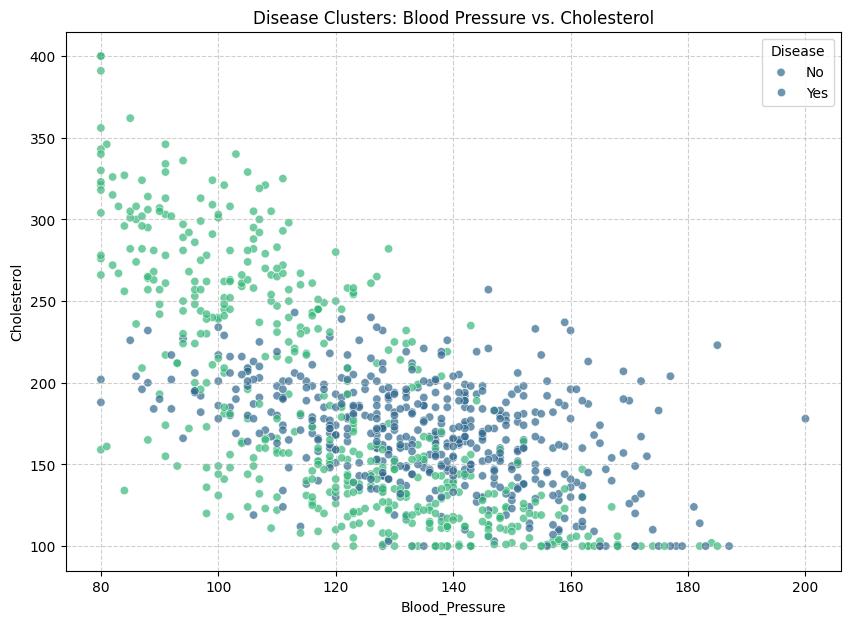

In [16]:
feature_names = df.columns[:-1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=x[:, df.columns.get_loc('Blood_Pressure')],
    y=x[:, df.columns.get_loc('Cholesterol')],
    hue=y,
    palette='viridis',
    alpha=0.7
)
plt.title('Disease Clusters: Blood Pressure vs. Cholesterol')
plt.xlabel(feature_names[df.columns.get_loc('Blood_Pressure')])
plt.ylabel(feature_names[df.columns.get_loc('Cholesterol')])
plt.legend(title='Disease', labels=['No', 'Yes'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Clustering and Visualization

To identify natural groupings within the data, we will apply a clustering algorithm. K-Means is a popular choice for this. Since we are dealing with a classification problem (disease present/absent), we'll start by looking for two clusters. After clustering, we'll use Principal Component Analysis (PCA) to reduce the data to two dimensions, allowing us to visualize the clusters on a scatter plot.

In [17]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Initialize KMeans with 2 clusters (assuming two primary groupings: diseased vs. non-diseased)
# We'll use a fixed random_state for reproducibility
kmeans = KMeans(n_clusters=2, random_state=90, n_init=10)

# Fit KMeans to the feature data (x) and get cluster assignments
clusters = kmeans.fit_predict(x)

print("Cluster assignments generated.")

Cluster assignments generated.


In [18]:
# Apply PCA to reduce the features to 2 dimensions for visualization
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

print("Data reduced to 2 dimensions using PCA.")

Data reduced to 2 dimensions using PCA.


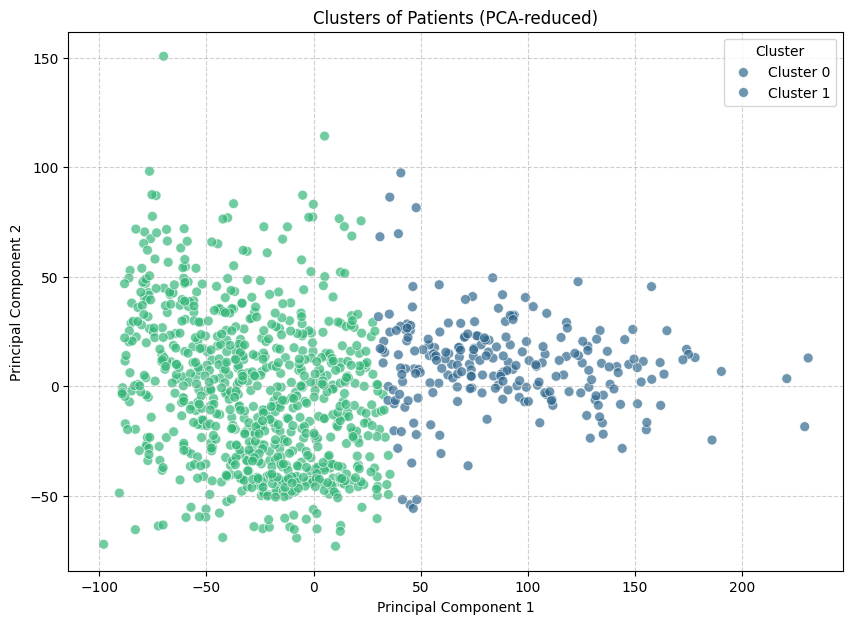

In [19]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=x_pca[:, 0],
    y=x_pca[:, 1],
    hue=clusters, # Color points by the assigned cluster
    palette='viridis',
    alpha=0.7,
    s=50 # Size of the points
)
plt.title('Clusters of Patients (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()